# Linear Regression with Diabetes Dataset
## Understanding Model Performance with Correlation Analysis and Heatmaps

This notebook demonstrates:
1. Loading the Diabetes dataset
2. Exploring correlations between features and target
3. Visualizing relationships with heatmaps
4. Building and evaluating a Linear Regression model

## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load and Explore the Diabetes Dataset

In [15]:
# Load the Diabetes dataset from sklearn
# This dataset contains 442 samples with 10 features
# The target is a quantitative measure of disease progression one year after baseline
diabetes = load_diabetes()

# Extract features (X) and target (y)
X = diabetes.data
y = diabetes.target

# Get feature names for better understanding
feature_names = diabetes.feature_names

print("=" * 60)
print("DIABETES DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset Shape: {X.shape}")
print(f"  - Samples (Patients): {X.shape[0]}")
print(f"  - Features: {X.shape[1]}")
print(f"\nFeature Names:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")
print(f"\nTarget Variable (Disease Progression):")
print(f"  - Min: {y.min():.2f}")
print(f"  - Max: {y.max():.2f}")
print(f"  - Mean: {y.mean():.2f}")
print(f"  - Std: {y.std():.2f}")

DIABETES DATASET OVERVIEW

Dataset Shape: (442, 10)
  - Samples (Patients): 442
  - Features: 10

Feature Names:
  1. age
  2. sex
  3. bmi
  4. bp
  5. s1
  6. s2
  7. s3
  8. s4
  9. s5
  10. s6

Target Variable (Disease Progression):
  - Min: 25.00
  - Max: 346.00
  - Mean: 152.13
  - Std: 77.01


In [16]:
# Create a DataFrame for easier manipulation and correlation analysis
df = pd.DataFrame(X, columns=feature_names)
df['Target_Disease_Progression'] = y

print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Target_Disease_Progression  
0 -0.002592  0.019907 -0.017646                       151.0  
1 -0.039493 -0.068332 -0.092204                        75.0  
2 -0.002592  0.002861 -0.025930                       141.0  
3  0.034309  0.022688 -0.009362                       206.0  
4 -0.002592 -0.031988 -0.046641                       135.0  


## 3. Correlation Analysis
### Understand which features are most related to disease progression

In [17]:
# Calculate correlation matrix
# Correlation shows how two variables move together
# Values range from -1 (negative correlation) to +1 (positive correlation)
correlation_matrix = df.corr()

# Extract correlations with target variable and sort them
target_correlation = correlation_matrix['Target_Disease_Progression'].sort_values(ascending=False)

print("\n" + "=" * 60)
print("CORRELATION WITH DISEASE PROGRESSION")
print("=" * 60)
print("\nCorrelation Coefficients (closer to 1 or -1 = stronger relationship):")
for feature, corr in target_correlation.items():
    if feature != 'Target_Disease_Progression':
        print(f"  {feature:25s}: {corr:7.4f}")


CORRELATION WITH DISEASE PROGRESSION

Correlation Coefficients (closer to 1 or -1 = stronger relationship):
  bmi                      :  0.5865
  s5                       :  0.5659
  bp                       :  0.4415
  s4                       :  0.4305
  s6                       :  0.3825
  s1                       :  0.2120
  age                      :  0.1879
  s2                       :  0.1741
  sex                      :  0.0431
  s3                       : -0.3948


## 4. Correlation Heatmap
### Visualize relationships between all features and target variable

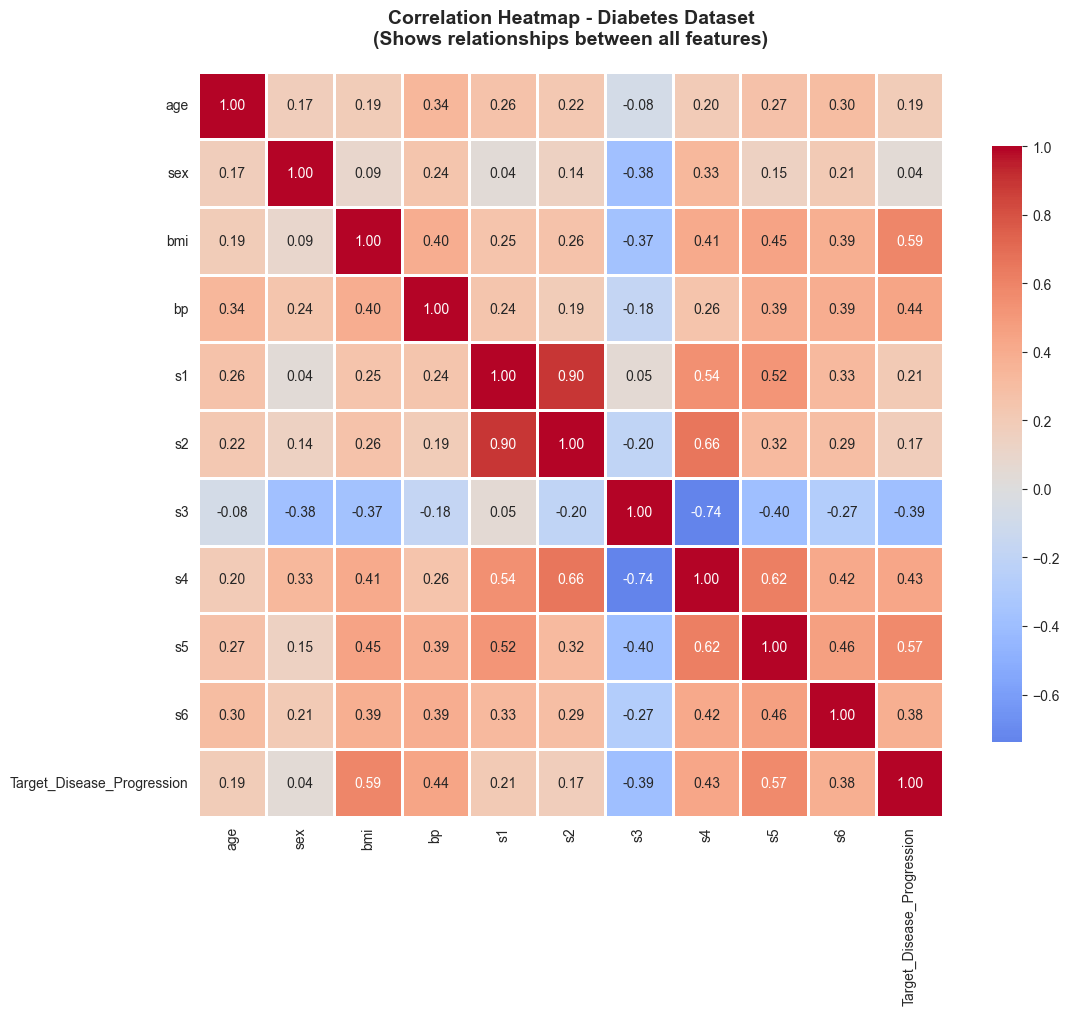


Heatmap Interpretation:
  - Red (positive): Features that increase together
  - Blue (negative): Features that decrease together
  - The last row shows how each feature relates to disease progression


In [18]:
# Create a heatmap to visualize correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Diabetes Dataset\n(Shows relationships between all features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nHeatmap Interpretation:")
print("  - Red (positive): Features that increase together")
print("  - Blue (negative): Features that decrease together")
print("  - The last row shows how each feature relates to disease progression")

## 5. Top Features Bar Plot
### Show which features have strongest correlation with disease progression

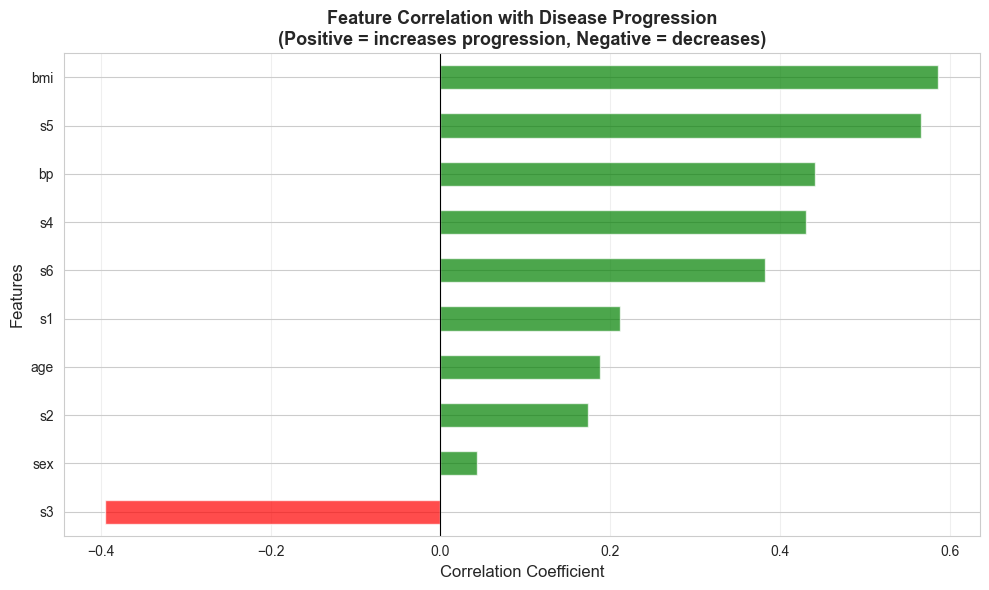

In [19]:
# Extract target correlations (excluding the target itself)
target_corr = target_correlation.drop('Target_Disease_Progression').sort_values()

# Create a bar plot
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Disease Progression\n(Positive = increases progression, Negative = decreases)', 
          fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Data Preparation
### Split data into training and testing sets

In [20]:
# Split the data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "=" * 60)
print("DATA SPLITTING")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  - Samples: {X_train.shape[0]}")
print(f"  - Features: {X_train.shape[1]}")
print(f"\nTesting Set:")
print(f"  - Samples: {X_test.shape[0]}")
print(f"  - Features: {X_test.shape[1]}")


DATA SPLITTING

Training Set:
  - Samples: 353
  - Features: 10

Testing Set:
  - Samples: 89
  - Features: 10


## 7. Train Linear Regression Model
### The model learns the relationship between features and disease progression

In [21]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)  # Fit on training data

print("\n" + "=" * 60)
print("LINEAR REGRESSION MODEL TRAINING")
print("=" * 60)
print("\nModel successfully trained on training set!")
print(f"\nModel Coefficients (weights for each feature):")
for feature, coef in zip(feature_names, model.coef_):
    print(f"  {feature:25s}: {coef:8.4f}")
print(f"\nIntercept (baseline value): {model.intercept_:.4f}")


LINEAR REGRESSION MODEL TRAINING

Model successfully trained on training set!

Model Coefficients (weights for each feature):
  age                      :  37.9040
  sex                      : -241.9644
  bmi                      : 542.4288
  bp                       : 347.7038
  s1                       : -931.4888
  s2                       : 518.0623
  s3                       : 163.4200
  s4                       : 275.3179
  s5                       : 736.1989
  s6                       :  48.6707

Intercept (baseline value): 151.3456


## 8. Make Predictions
### Use the trained model to predict disease progression on test data

In [22]:
# Make predictions on both training and test sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Show sample predictions vs actual values
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS (First 10 test samples)")
print("=" * 60)
print(f"\n{'Actual':>10} | {'Predicted':>10} | {'Error':>10}")
print("-" * 35)
for i in range(min(10, len(y_test))):
    error = y_test[i] - y_pred_test[i]
    print(f"{y_test[i]:10.2f} | {y_pred_test[i]:10.2f} | {error:10.2f}")


SAMPLE PREDICTIONS (First 10 test samples)

    Actual |  Predicted |      Error
-----------------------------------
    219.00 |     139.55 |      79.45
     70.00 |     179.52 |    -109.52
    202.00 |     134.04 |      67.96
    230.00 |     291.42 |     -61.42
    111.00 |     123.79 |     -12.79
     84.00 |      92.17 |      -8.17
    242.00 |     258.23 |     -16.23
    272.00 |     181.34 |      90.66
     94.00 |      90.22 |       3.78
     96.00 |     108.63 |     -12.63


## 9. Model Evaluation
### Assess how well the model performs using multiple metrics

In [23]:
# Calculate evaluation metrics
# R² Score: 1 is perfect, 0 means model explains nothing
# MSE: Lower is better (measures average squared error)
# MAE: Lower is better (measures average absolute error)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
print("\nR² Score (Coefficient of Determination)")
print("  - Explains what % of variance is captured by model")
print(f"  - Training: {r2_train:.4f}")
print(f"  - Testing:  {r2_test:.4f}")

print("\nMean Squared Error (MSE)")
print("  - Average of squared differences between predicted and actual")
print(f"  - Training: {mse_train:.4f}")
print(f"  - Testing:  {mse_test:.4f}")

print("\nMean Absolute Error (MAE)")
print("  - Average of absolute differences between predicted and actual")
print(f"  - Training: {mae_train:.4f}")
print(f"  - Testing:  {mae_test:.4f}")

# Check for overfitting
print("\n" + "-" * 60)
print("Overfitting Analysis:")
diff_r2 = r2_train - r2_test
print(f"  - R² difference (train - test): {diff_r2:.4f}")
if diff_r2 > 0.05:
    print("  ⚠️  Model shows signs of overfitting")
else:
    print("  ✓ Model generalizes well to unseen data")


MODEL PERFORMANCE METRICS

R² Score (Coefficient of Determination)
  - Explains what % of variance is captured by model
  - Training: 0.5279
  - Testing:  0.4526

Mean Squared Error (MSE)
  - Average of squared differences between predicted and actual
  - Training: 2868.5497
  - Testing:  2900.1936

Mean Absolute Error (MAE)
  - Average of absolute differences between predicted and actual
  - Training: 43.4835
  - Testing:  42.7941

------------------------------------------------------------
Overfitting Analysis:
  - R² difference (train - test): 0.0753
  ⚠️  Model shows signs of overfitting


## 10. Visualization - Actual vs Predicted

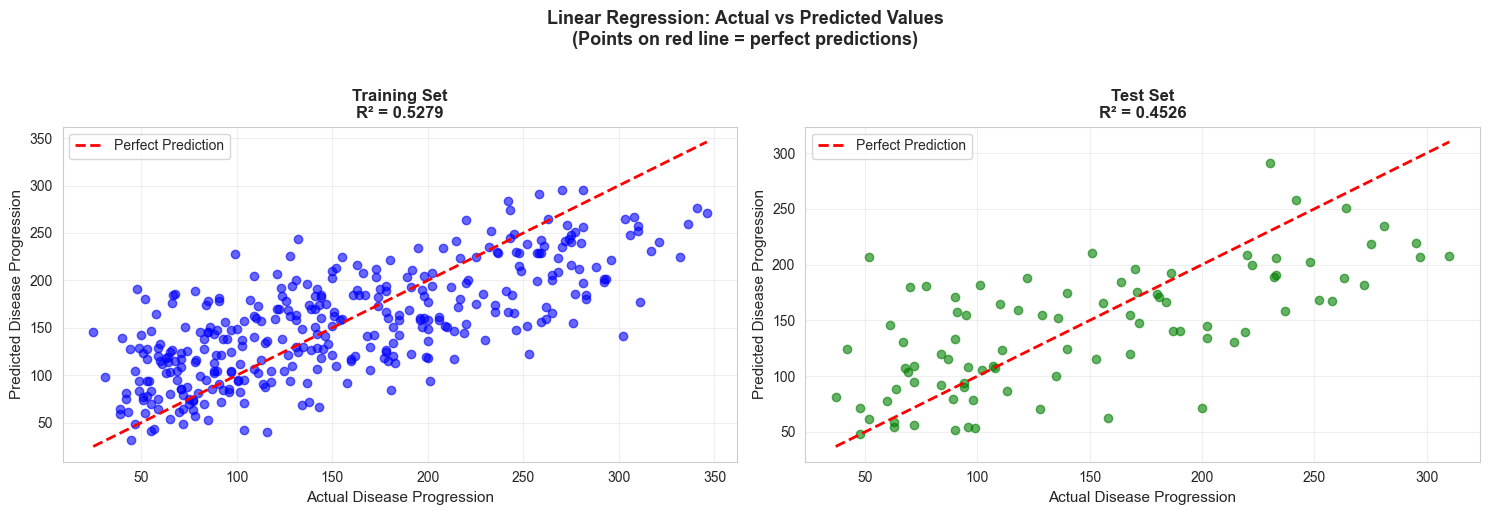

In [24]:
# Create a scatter plot comparing actual vs predicted values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training set
axes[0].scatter(y_train, y_pred_train, alpha=0.6, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Disease Progression', fontsize=11)
axes[0].set_ylabel('Predicted Disease Progression', fontsize=11)
axes[0].set_title(f'Training Set\nR² = {r2_train:.4f}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test set
axes[1].scatter(y_test, y_pred_test, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Disease Progression', fontsize=11)
axes[1].set_ylabel('Predicted Disease Progression', fontsize=11)
axes[1].set_title(f'Test Set\nR² = {r2_test:.4f}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Linear Regression: Actual vs Predicted Values\n(Points on red line = perfect predictions)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Residual Analysis
### Check the distribution of prediction errors

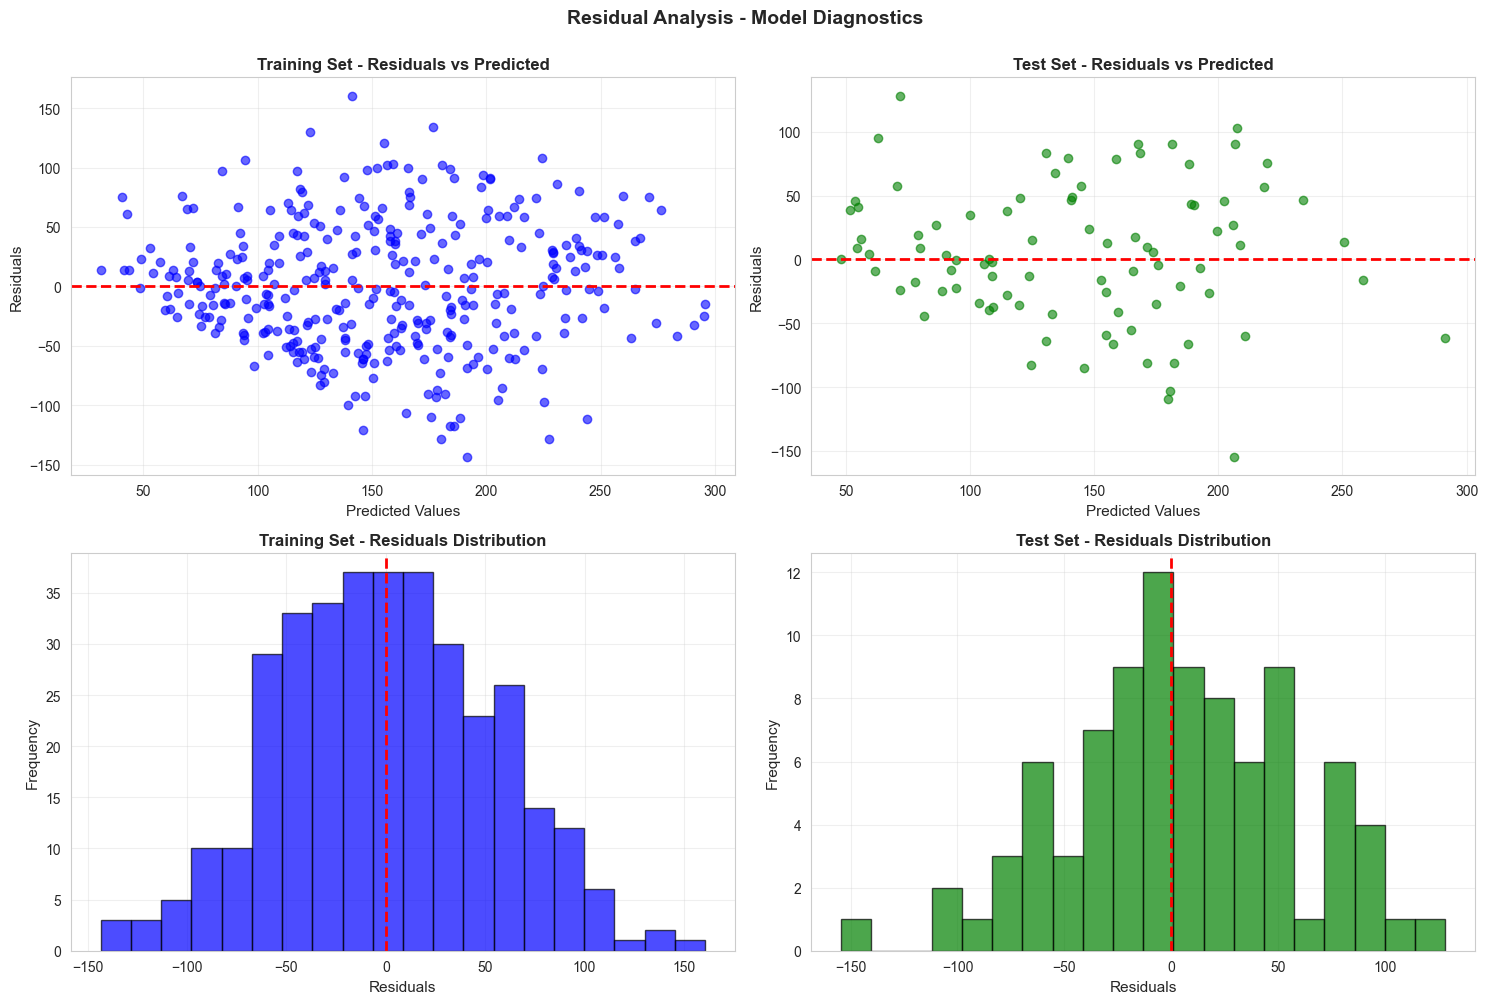


Residual Statistics:
  Mean of residuals (training): -0.0000
  Std of residuals (training):  53.5588
  Mean of residuals (test):     3.9128
  Std of residuals (test):      53.7111


In [25]:
# Calculate residuals (prediction errors)
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residuals vs Predicted - Training
axes[0, 0].scatter(y_pred_train, residuals_train, alpha=0.6, color='blue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Training Set - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Residuals vs Predicted - Test
axes[0, 1].scatter(y_pred_test, residuals_test, alpha=0.6, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=11)
axes[0, 1].set_ylabel('Residuals', fontsize=11)
axes[0, 1].set_title('Test Set - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Histogram of Residuals - Training
axes[1, 0].hist(residuals_train, bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Training Set - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Histogram of Residuals - Test
axes[1, 1].hist(residuals_test, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Test Set - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Residual Analysis - Model Diagnostics', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nResidual Statistics:")
print(f"  Mean of residuals (training): {residuals_train.mean():.4f}")
print(f"  Std of residuals (training):  {residuals_train.std():.4f}")
print(f"  Mean of residuals (test):     {residuals_test.mean():.4f}")
print(f"  Std of residuals (test):      {residuals_test.std():.4f}")

## 12. Summary & Conclusions

In [26]:
print("\n" + "=" * 60)
print("MODEL SUMMARY & KEY INSIGHTS")
print("=" * 60)

print("\n1. CORRELATION INSIGHTS:")
top_3_corr = target_correlation.drop('Target_Disease_Progression').abs().sort_values(ascending=False).head(3)
for i, (feature, corr) in enumerate(top_3_corr.items(), 1):
    print(f"   - Feature #{i}: {feature} (correlation: {target_correlation[feature]:.4f})")

print("\n2. MODEL PERFORMANCE:")
print(f"   - R² Test Score: {r2_test:.4f}")
print(f"     (Model explains {r2_test*100:.2f}% of variance in test data)")
print(f"   - MAE Test: {mae_test:.4f}")
print(f"     (Average prediction error: ±{mae_test:.2f} units)")

print("\n3. MODEL BEHAVIOR:")
if r2_train > r2_test:
    print("   ✓ Model generalizes well (slight overfitting is normal)")
else:
    print("   ⚠️  Model may be underfitting")

print("\n4. HOW THE MODEL WORKS:")
print(f"   Disease Progression = {model.intercept_:.2f}")
for feature, coef in zip(feature_names, model.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f"       {sign} {abs(coef):.4f} × {feature}")

print("\n" + "=" * 60)


MODEL SUMMARY & KEY INSIGHTS

1. CORRELATION INSIGHTS:
   - Feature #1: bmi (correlation: 0.5865)
   - Feature #2: s5 (correlation: 0.5659)
   - Feature #3: bp (correlation: 0.4415)

2. MODEL PERFORMANCE:
   - R² Test Score: 0.4526
     (Model explains 45.26% of variance in test data)
   - MAE Test: 42.7941
     (Average prediction error: ±42.79 units)

3. MODEL BEHAVIOR:
   ✓ Model generalizes well (slight overfitting is normal)

4. HOW THE MODEL WORKS:
   Disease Progression = 151.35
       + 37.9040 × age
       - 241.9644 × sex
       + 542.4288 × bmi
       + 347.7038 × bp
       - 931.4888 × s1
       + 518.0623 × s2
       + 163.4200 × s3
       + 275.3179 × s4
       + 736.1989 × s5
       + 48.6707 × s6

